In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

In [8]:
df = pd.read_csv("data/WBCD_dataset.csv")  # or WBCD_prognosis.csv

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,R,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,R,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,R,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,R,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,R,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
df["diagnosis"].value_counts()

diagnosis
N    357
R    212
Name: count, dtype: int64

In [10]:
# --- Label Mapping: R/N → Benign/Malignant ---

LABEL_MAP = {"R": 1, "N": 0}

# Normalize text
df["diagnosis"] = (
    df["diagnosis"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Validate labels
unexpected = set(df["diagnosis"].unique()) - set(LABEL_MAP.keys())
if unexpected:
    raise ValueError(f"Unexpected labels found: {unexpected}")

# Create readable medical label
df["diagnosis_label"] = df["diagnosis"].map({
    "R": "Malignant",
    "N": "Benign"
})

# Create numeric target
df["target"] = df["diagnosis"].map(LABEL_MAP)

# Drop original column
df.drop(columns=["diagnosis"], inplace=True)

df["target"].value_counts()

target
0    357
1    212
Name: count, dtype: int64

In [11]:
if "Unnamed: 32" in df.columns:
    df.drop(columns=["Unnamed: 32"], inplace=True)

In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df = df.drop_duplicates()

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


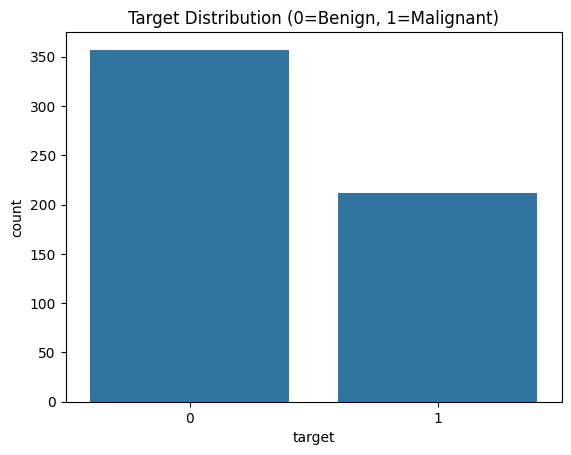

In [16]:
sns.countplot(x="target", data=df)
plt.title("Target Distribution (0=Benign, 1=Malignant)")
plt.show()

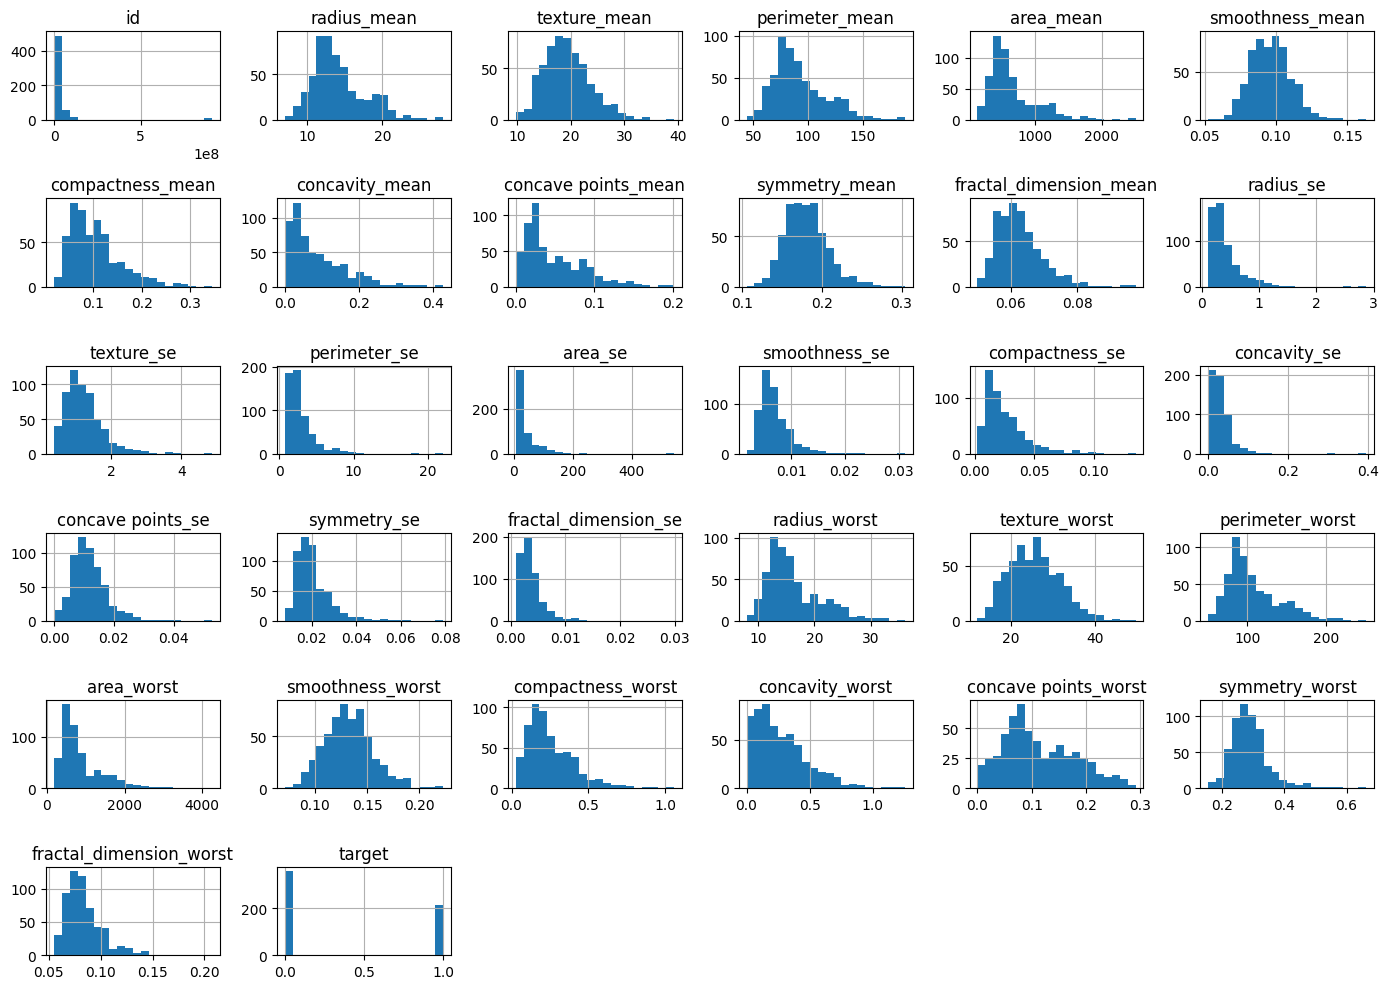

In [17]:
df.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

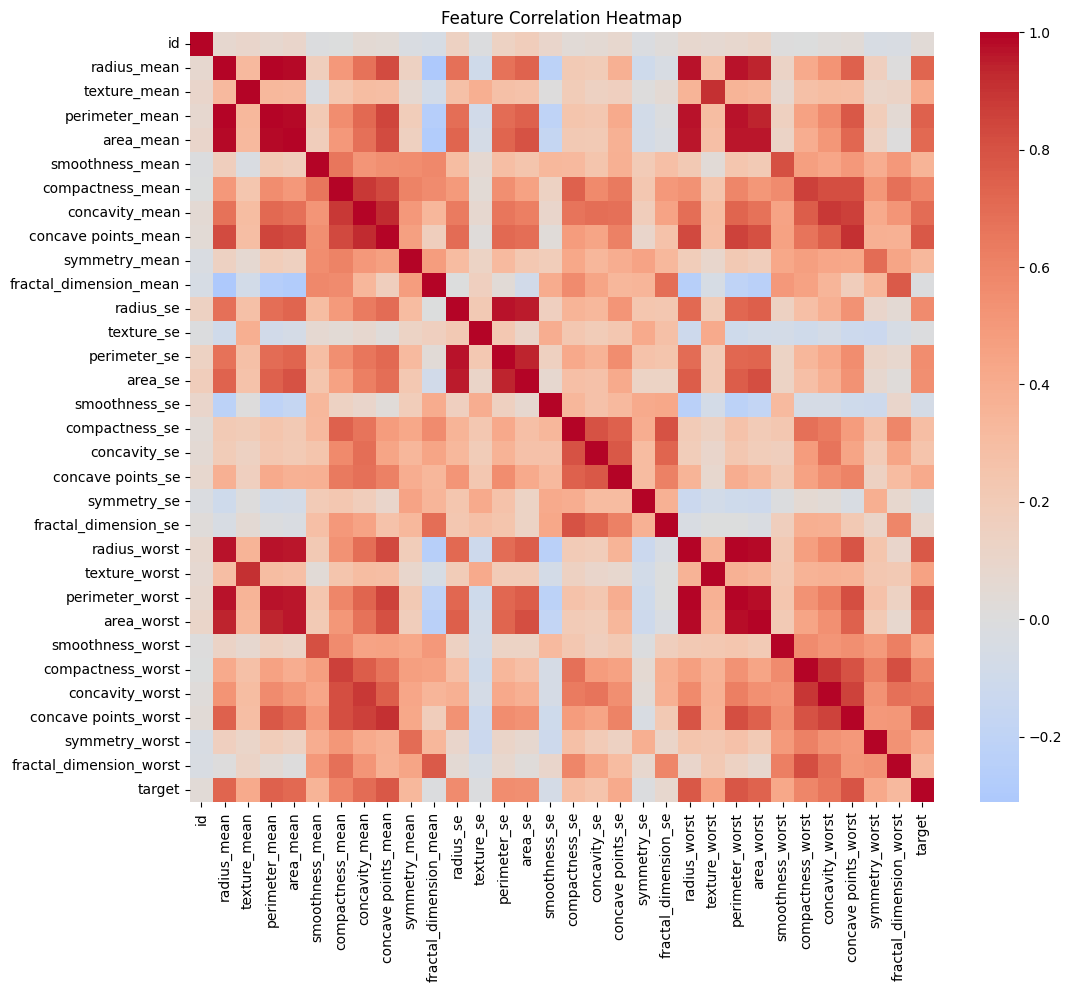

In [18]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
# Export the cleaned dataframe to CSV for downstream modeling.
# Uncomment the line below to save.
#df.to_csv('data/clean_WBCD.csv')